# BPCRR-INLA Merged Output Visualization

This notebook validates and visualizes merged BPCRR-INLA rank-selection outputs against shard-level outputs.

## Simple Comparison Notebook

Goal:
- One figure averaged over selected target islands (default 11)
- One grid with one panel per selected target island
- BPCRR merged results + optional ridge overlay from another output folder

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

cwd = Path.cwd().resolve()
root_candidates = [cwd, cwd.parent, cwd.parent.parent]
PROJECT_ROOT = next((p for p in root_candidates if (p / "outputs").exists()), cwd)

# Main run (used for all standard BPCRR curves and baselines).
BPCRR_MAIN_DIR = PROJECT_ROOT / "outputs" / "bpcrr_inla_2.0"
# Optional extra run: only PEV-based BPCRR curves should be taken from here.
BPCRR_PEV_DIR = PROJECT_ROOT / "outputs" / "bpcrr_inla_pev"

RIDGE_PCA_DIR = PROJECT_ROOT / "outputs" / "pca_source_rank_weight_test4"   # set to None to disable
RIDGE_AVGGRM_DIR = PROJECT_ROOT / "outputs" / "avggrm_rank_weight_all" / "body_mass"  # set to None to disable

print("PROJECT_ROOT:", PROJECT_ROOT)
print("BPCRR_MAIN_DIR exists:", BPCRR_MAIN_DIR.exists())
print("BPCRR_PEV_DIR exists:", BPCRR_PEV_DIR.exists() if BPCRR_PEV_DIR is not None else False)
print("RIDGE_PCA_DIR exists:", RIDGE_PCA_DIR.exists() if RIDGE_PCA_DIR is not None else False)
print("RIDGE_AVGGRM_DIR exists:", RIDGE_AVGGRM_DIR.exists() if RIDGE_AVGGRM_DIR is not None else False)

PROJECT_ROOT: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis
BPCRR_MAIN_DIR exists: True
BPCRR_PEV_DIR exists: True
RIDGE_PCA_DIR exists: True
RIDGE_AVGGRM_DIR exists: True


## Load BPCRR and Optional Ridge

In [2]:
def _find_csv(base_dir: Path, filename: str) -> Path | None:
    candidates = [
        base_dir / filename,
        *sorted(base_dir.glob(f"*/{filename}")),
        *sorted(base_dir.glob(f"*/*/{filename}")),
    ]
    return next((p for p in candidates if p.exists()), None)


def _load_and_standardize(path: Path, model_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    rename_map = {}
    if "selection_method" in df.columns and "method" not in df.columns:
        rename_map["selection_method"] = "method"
    if "n_train_size" in df.columns and "n_individuals" not in df.columns:
        rename_map["n_train_size"] = "n_individuals"
    if rename_map:
        df = df.rename(columns=rename_map)

    required = ["target_island", "n_individuals", "corr_eval"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{model_name}: missing required columns {missing} in {path}")

    if "method" not in df.columns:
        df["method"] = model_name

    df["target_island"] = pd.to_numeric(df["target_island"], errors="coerce")
    df["n_individuals"] = pd.to_numeric(df["n_individuals"], errors="coerce")
    df["corr_eval"] = pd.to_numeric(df["corr_eval"], errors="coerce")
    df = df.dropna(subset=["target_island", "n_individuals", "corr_eval"]).copy()
    df["target_island"] = df["target_island"].astype(int)
    df["n_individuals"] = df["n_individuals"].astype(int)
    df["model"] = model_name
    return df


def _keep_pev_methods(df: pd.DataFrame) -> pd.DataFrame:
    # Only keep explicit PEV curves from the supplemental run.
    mask = df["method"].astype(str).str.contains("pev", case=False, na=False)
    return df[mask].copy()


bpcrr_main_path = _find_csv(BPCRR_MAIN_DIR, "bpcrr_inla_rank_select_results.csv")
if bpcrr_main_path is None:
    raise FileNotFoundError("Could not find bpcrr_inla_rank_select_results.csv in BPCRR_MAIN_DIR")
bpcrr_main = _load_and_standardize(bpcrr_main_path, "bpcrr")
print("Loaded BPCRR main:", bpcrr_main_path, bpcrr_main.shape)

parts = [bpcrr_main]

bpcrr_pev = pd.DataFrame()
bpcrr_pev_path = None
if BPCRR_PEV_DIR is not None:
    bpcrr_pev_path = _find_csv(BPCRR_PEV_DIR, "bpcrr_inla_rank_select_results.csv")
    if bpcrr_pev_path is not None:
        bpcrr_pev_all = _load_and_standardize(bpcrr_pev_path, "bpcrr")
        bpcrr_pev = _keep_pev_methods(bpcrr_pev_all)
        if not bpcrr_pev.empty:
            parts.append(bpcrr_pev)
            print("Loaded BPCRR PEV curves:", bpcrr_pev_path, bpcrr_pev.shape)
        else:
            print("No PEV-labeled methods found in:", bpcrr_pev_path)
    else:
        print("BPCRR PEV source file not found under", BPCRR_PEV_DIR)

bpcrr_selected_path = _find_csv(BPCRR_PEV_DIR, "bpcrr_inla_ranked_selected_individuals.csv") if BPCRR_PEV_DIR is not None else None
bpcrr_selected = pd.DataFrame()
if bpcrr_selected_path is not None:
    bpcrr_selected = pd.read_csv(bpcrr_selected_path)
    print("Loaded BPCRR selected individuals:", bpcrr_selected_path, bpcrr_selected.shape)
    cols = [c for c in ["trait", "target_island", "method", "n_train_size", "ringnr"] if c in bpcrr_selected.columns]
    if cols:
        display(bpcrr_selected[cols].head(10))
    else:
        display(bpcrr_selected.head(10))

    summary_cols = [c for c in ["trait", "target_island", "method", "n_train_size"] if c in bpcrr_selected.columns]
    if summary_cols:
        bpcrr_selected_summary = (
            bpcrr_selected.groupby(summary_cols, dropna=False, as_index=False)
            .size()
            .rename(columns={"size": "n_selected_rows"})
            .sort_values(summary_cols)
        )
        print("BPCRR selected summary (first 20 rows):")
        display(bpcrr_selected_summary.head(20))
else:
    print("BPCRR selected individuals file not found under", BPCRR_PEV_DIR)

ridge_pca = pd.DataFrame()
if RIDGE_PCA_DIR is not None:
    ridge_pca_path = _find_csv(RIDGE_PCA_DIR, "pca_source_rank_weight_results.csv")
    if ridge_pca_path is not None:
        ridge_pca = _load_and_standardize(ridge_pca_path, "ridge_pca")
        parts.append(ridge_pca)
        print("Loaded ridge PCA:", ridge_pca_path, ridge_pca.shape)
    else:
        print("Ridge PCA results file not found under", RIDGE_PCA_DIR)

ridge_avggrm = pd.DataFrame()
if RIDGE_AVGGRM_DIR is not None:
    ridge_avggrm_path = _find_csv(RIDGE_AVGGRM_DIR, "avggrm_rank_weight_results.csv")
    if ridge_avggrm_path is not None:
        ridge_avggrm = _load_and_standardize(ridge_avggrm_path, "ridge_avggrm")
        parts.append(ridge_avggrm)
        print("Loaded ridge avgGRM:", ridge_avggrm_path, ridge_avggrm.shape)
    else:
        print("Ridge avgGRM results file not found under", RIDGE_AVGGRM_DIR)

combined = pd.concat(parts, ignore_index=True)

available_islands = sorted(combined["target_island"].unique().tolist())
target_islands_to_plot = available_islands

# -------------------------------
# Plot controls (easy to edit)
# -------------------------------
PLOT_MODELS = ["bpcrr", "ridge_pca", "ridge_avggrm"]
PLOT_METHODS = None  # Example: ["bpcrr_topk_avggrm", "bpcrr_topk_pc_distance", "bpcrr_topk_bpcrr_pev_ga", "random_individual", "avggrm_topk", "pca_source_topk"]
EXCLUDE_METHODS = []
USE_RANKED_SUBSET_ONLY = True

# How to handle duplicated random lines from ridge runs:
# "all"            -> keep all random lines
# "keep_one_ridge" -> keep random_individual only for RIDGE_RANDOM_KEEP model
# "average_ridge"  -> average random_individual across all ridge models into one synthetic model "ridge_random_avg"
RANDOM_POLICY = "keep_one_ridge"
RIDGE_RANDOM_KEEP = "ridge_avggrm"

# Collapse ridge variants to one display model to avoid duplicate full-source baselines.
COLLAPSE_RIDGE_DISPLAY = True


def _display_model_name(model: str) -> str:
    if COLLAPSE_RIDGE_DISPLAY and str(model).startswith("ridge"):
        return "ridge"
    return str(model)


def _apply_plot_filters(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out[out["target_island"].isin(target_islands_to_plot)]

    if USE_RANKED_SUBSET_ONLY and "analysis" in out.columns:
        ranked_only = out[out["analysis"] == "ranked_subset"]
        if len(ranked_only):
            out = ranked_only

    if PLOT_MODELS is not None:
        out = out[out["model"].isin(PLOT_MODELS)]

    if PLOT_METHODS is not None:
        out = out[out["method"].isin(PLOT_METHODS)]

    if EXCLUDE_METHODS:
        out = out[~out["method"].isin(EXCLUDE_METHODS)]

    if RANDOM_POLICY == "keep_one_ridge":
        mask_drop = (
            (out["method"] == "random_individual")
            & (out["model"].str.startswith("ridge"))
            & (out["model"] != RIDGE_RANDOM_KEEP)
        )
        out = out[~mask_drop]
    elif RANDOM_POLICY == "average_ridge":
        is_ridge_random = (out["method"] == "random_individual") & (out["model"].str.startswith("ridge"))
        ridge_rand = out[is_ridge_random]
        non_rand = out[~is_ridge_random]
        if len(ridge_rand):
            avg_rand = (
                ridge_rand.groupby(["target_island", "n_individuals", "method"], as_index=False)["corr_eval"]
                .mean()
                .assign(model="ridge_random_avg")
            )
            out = pd.concat([non_rand, avg_rand], ignore_index=True)
        else:
            out = non_rand

    out["model_display"] = out["model"].map(_display_model_name)
    return out


plot_data = _apply_plot_filters(combined)

# Full-source references are deduplicated to one baseline row per model+target.
# Since only PEV methods are imported from BPCRR_PEV_DIR, BPCRR full baseline comes from main run.
full_source_refs = combined.copy()
if "analysis" in full_source_refs.columns:
    full_source_refs = full_source_refs[full_source_refs["analysis"] == "full_baseline"]
full_source_refs = full_source_refs[full_source_refs["method"] == "full_source_unweighted"]

if PLOT_MODELS is not None:
    full_source_refs = full_source_refs[full_source_refs["model"].isin(PLOT_MODELS)]
full_source_refs = full_source_refs[full_source_refs["target_island"].isin(target_islands_to_plot)]

sort_cols = [c for c in ["model", "target_island", "repeat", "repeat_seed"] if c in full_source_refs.columns]
if sort_cols:
    full_source_refs = full_source_refs.sort_values(sort_cols)
full_source_refs = full_source_refs.drop_duplicates(subset=["model", "target_island"], keep="first")
full_source_refs["model_display"] = full_source_refs["model"].map(_display_model_name)

print("Combined rows:", len(combined))
print("Plot rows after filters:", len(plot_data))
print("Models in plot:", sorted(plot_data["model"].unique().tolist()))
print("Display models:", sorted(plot_data["model_display"].unique().tolist()))
print("Methods in plot:", sorted(plot_data["method"].astype(str).unique().tolist()))
print("Target islands to plot:", target_islands_to_plot)
print("BPCRR main source file:", bpcrr_main_path)
print("BPCRR PEV source file:", bpcrr_pev_path)
print("Full-source reference rows (deduplicated):", len(full_source_refs))

Loaded BPCRR main: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\bpcrr_inla_2.0\bpcrr_inla_rank_select_results.csv (1024, 18)
Loaded BPCRR PEV curves: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\bpcrr_inla_pev\bpcrr_inla_rank_select_results.csv (144, 18)
Loaded BPCRR selected individuals: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\bpcrr_inla_pev\bpcrr_inla_ranked_selected_individuals.csv (360000, 17)


,trait,target_island,method,n_train_size,ringnr
0,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L19578
1,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L19729
2,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L19877
3,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L19919
4,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L19953
5,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L19992
6,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L19998
7,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L26597
8,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L30363
9,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,8L30446


BPCRR selected summary (first 20 rows):


,trait,target_island,method,n_train_size,n_selected_rows
0,body_mass,0,bpcrr_topk_bpcrr_pev_ga,500,500
1,body_mass,0,bpcrr_topk_bpcrr_pev_ga,1000,1000
2,body_mass,0,bpcrr_topk_bpcrr_pev_ga,1500,1500
3,body_mass,0,bpcrr_topk_bpcrr_pev_ga,2000,2000
4,body_mass,0,bpcrr_topk_bpcrr_pev_ga,2500,2500
5,body_mass,0,bpcrr_topk_bpcrr_pev_ga,3000,3000
6,body_mass,0,bpcrr_topk_bpcrr_pev_ga,3500,3500
7,body_mass,0,bpcrr_topk_bpcrr_pev_ga,4000,4000
8,body_mass,0,bpcrr_topk_bpcrr_pev_ga,4500,4500
9,body_mass,1,bpcrr_topk_bpcrr_pev_ga,500,500


Loaded ridge PCA: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\pca_source_rank_weight_test4\pca_source_rank_weight_results.csv (1712, 21)
Loaded ridge avgGRM: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\avggrm_rank_weight_all\body_mass\avggrm_rank_weight_results.csv (2208, 15)
Combined rows: 5088
Plot rows after filters: 3408
Models in plot: ['bpcrr', 'ridge_avggrm', 'ridge_pca']
Display models: ['bpcrr', 'ridge']
Methods in plot: ['avggrm_topk', 'bpcrr_topk_avggrm', 'bpcrr_topk_bpcrr_pev_ga', 'bpcrr_topk_pc_distance', 'pca_source_topk', 'random_individual']
Target islands to plot: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
BPCRR main source file: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\bpcrr_inla_2.0\bpcrr_inla_rank_select_results.csv
BPCRR PEV source file: C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\bpcrr_inla_pev\bpcrr_inla_rank_select_results.csv
Fu

## Figure 1: Mean Performance Over Selected Islands (default 11)

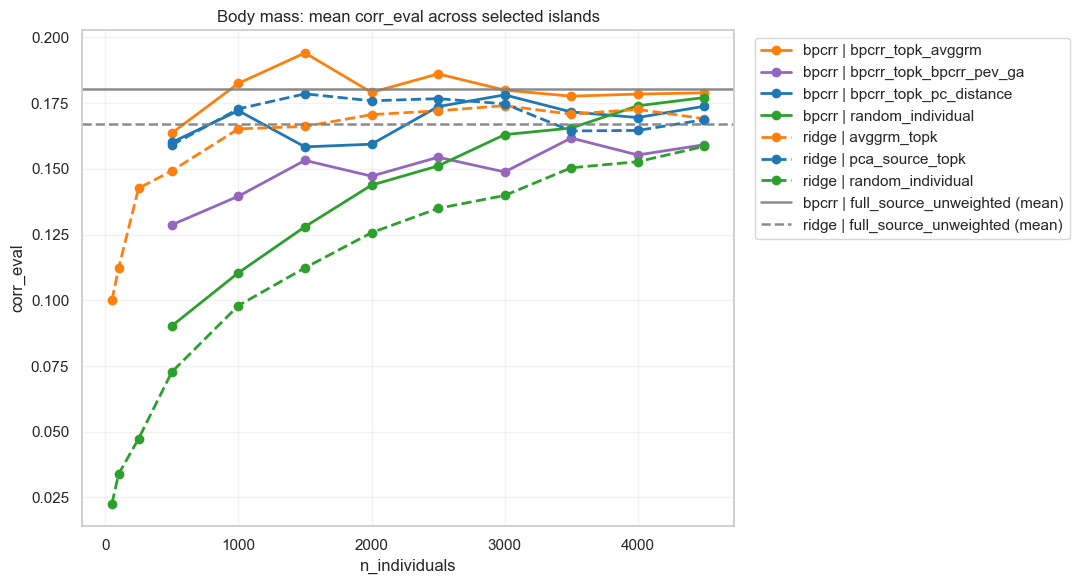

In [3]:
linestyles = ["-", "--", "-.", ":"]


def method_family(method: str) -> str:
    m = str(method).lower()
    if "full_source" in m:
        return "full_source"
    if "random" in m:
        return "random"
    if "avggrm" in m:
        return "avggrm"
    if "delta_ld" in m:
        return "delta_ld"

    # Match PC-based methods explicitly; do not match the "pc" inside "bpcrr".
    pc_tokens = ["pc_distance", "pca_source", "_pc_", "_pca_"]
    if any(tok in m for tok in pc_tokens) or m.startswith("pc_") or m.startswith("pca_"):
        return "pc"

    return "other"


def model_linestyle(model_display: str) -> str:
    return "-" if str(model_display).lower() == "bpcrr" else "--"


family_colors = {
    "random": "#2ca02c",      # green
    "pc": "#1f77b4",          # blue
    "avggrm": "#ff7f0e",      # orange
    "delta_ld": "#d62728",    # red
    "full_source": "#7f7f7f", # gray
    "other": "#9467bd",       # fallback
}

# Figure-1-specific trigger
REMOVE_BPCRR_FROM_FIG1 = False

# Mean corr_eval across selected islands vs n_individuals
plot_df = (
    plot_data.groupby(["model_display", "method", "n_individuals"], as_index=False)["corr_eval"]
    .mean()
    .sort_values(["model_display", "method", "n_individuals"])
)

if REMOVE_BPCRR_FROM_FIG1:
    plot_df = plot_df[plot_df["model_display"] != "bpcrr"].copy()

if plot_df.empty:
    raise ValueError("No rows to plot after filters. Relax PLOT_MODELS/PLOT_METHODS or USE_RANKED_SUBSET_ONLY.")

plot_df["curve"] = plot_df["model_display"] + " | " + plot_df["method"]
curve_specs = (
    plot_df[["curve", "model_display", "method"]]
    .drop_duplicates()
    .sort_values(["model_display", "method"]) 
)

plt.figure(figsize=(11, 6))
for _, spec in curve_specs.iterrows():
    curve = spec["curve"]
    sub = plot_df[plot_df["curve"] == curve]
    fam = method_family(spec["method"])
    plt.plot(
        sub["n_individuals"],
        sub["corr_eval"],
        marker="o",
        linewidth=2,
        color=family_colors.get(fam, family_colors["other"]),
        linestyle=model_linestyle(spec["model_display"]),
        label=curve,
    )

# Horizontal reference lines: full_source_unweighted mean over selected islands per display model
if not full_source_refs.empty:
    fs_mean = (
        full_source_refs.groupby("model_display", as_index=False)["corr_eval"]
        .mean()
        .sort_values("model_display")
    )
    if REMOVE_BPCRR_FROM_FIG1:
        fs_mean = fs_mean[fs_mean["model_display"] != "bpcrr"]

    for _, row in fs_mean.iterrows():
        plt.axhline(
            row["corr_eval"],
            linestyle=model_linestyle(row["model_display"]),
            linewidth=1.8,
            alpha=0.9,
            color=family_colors["full_source"],
            label=f"{row['model_display']} | full_source_unweighted (mean)",
        )

plt.title("Body mass: mean corr_eval across selected islands")
plt.xlabel("n_individuals")
plt.ylabel("corr_eval")
plt.grid(True, alpha=0.25)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Figure 2: One Panel Per Target Island

Using island labels from column: target_island_name


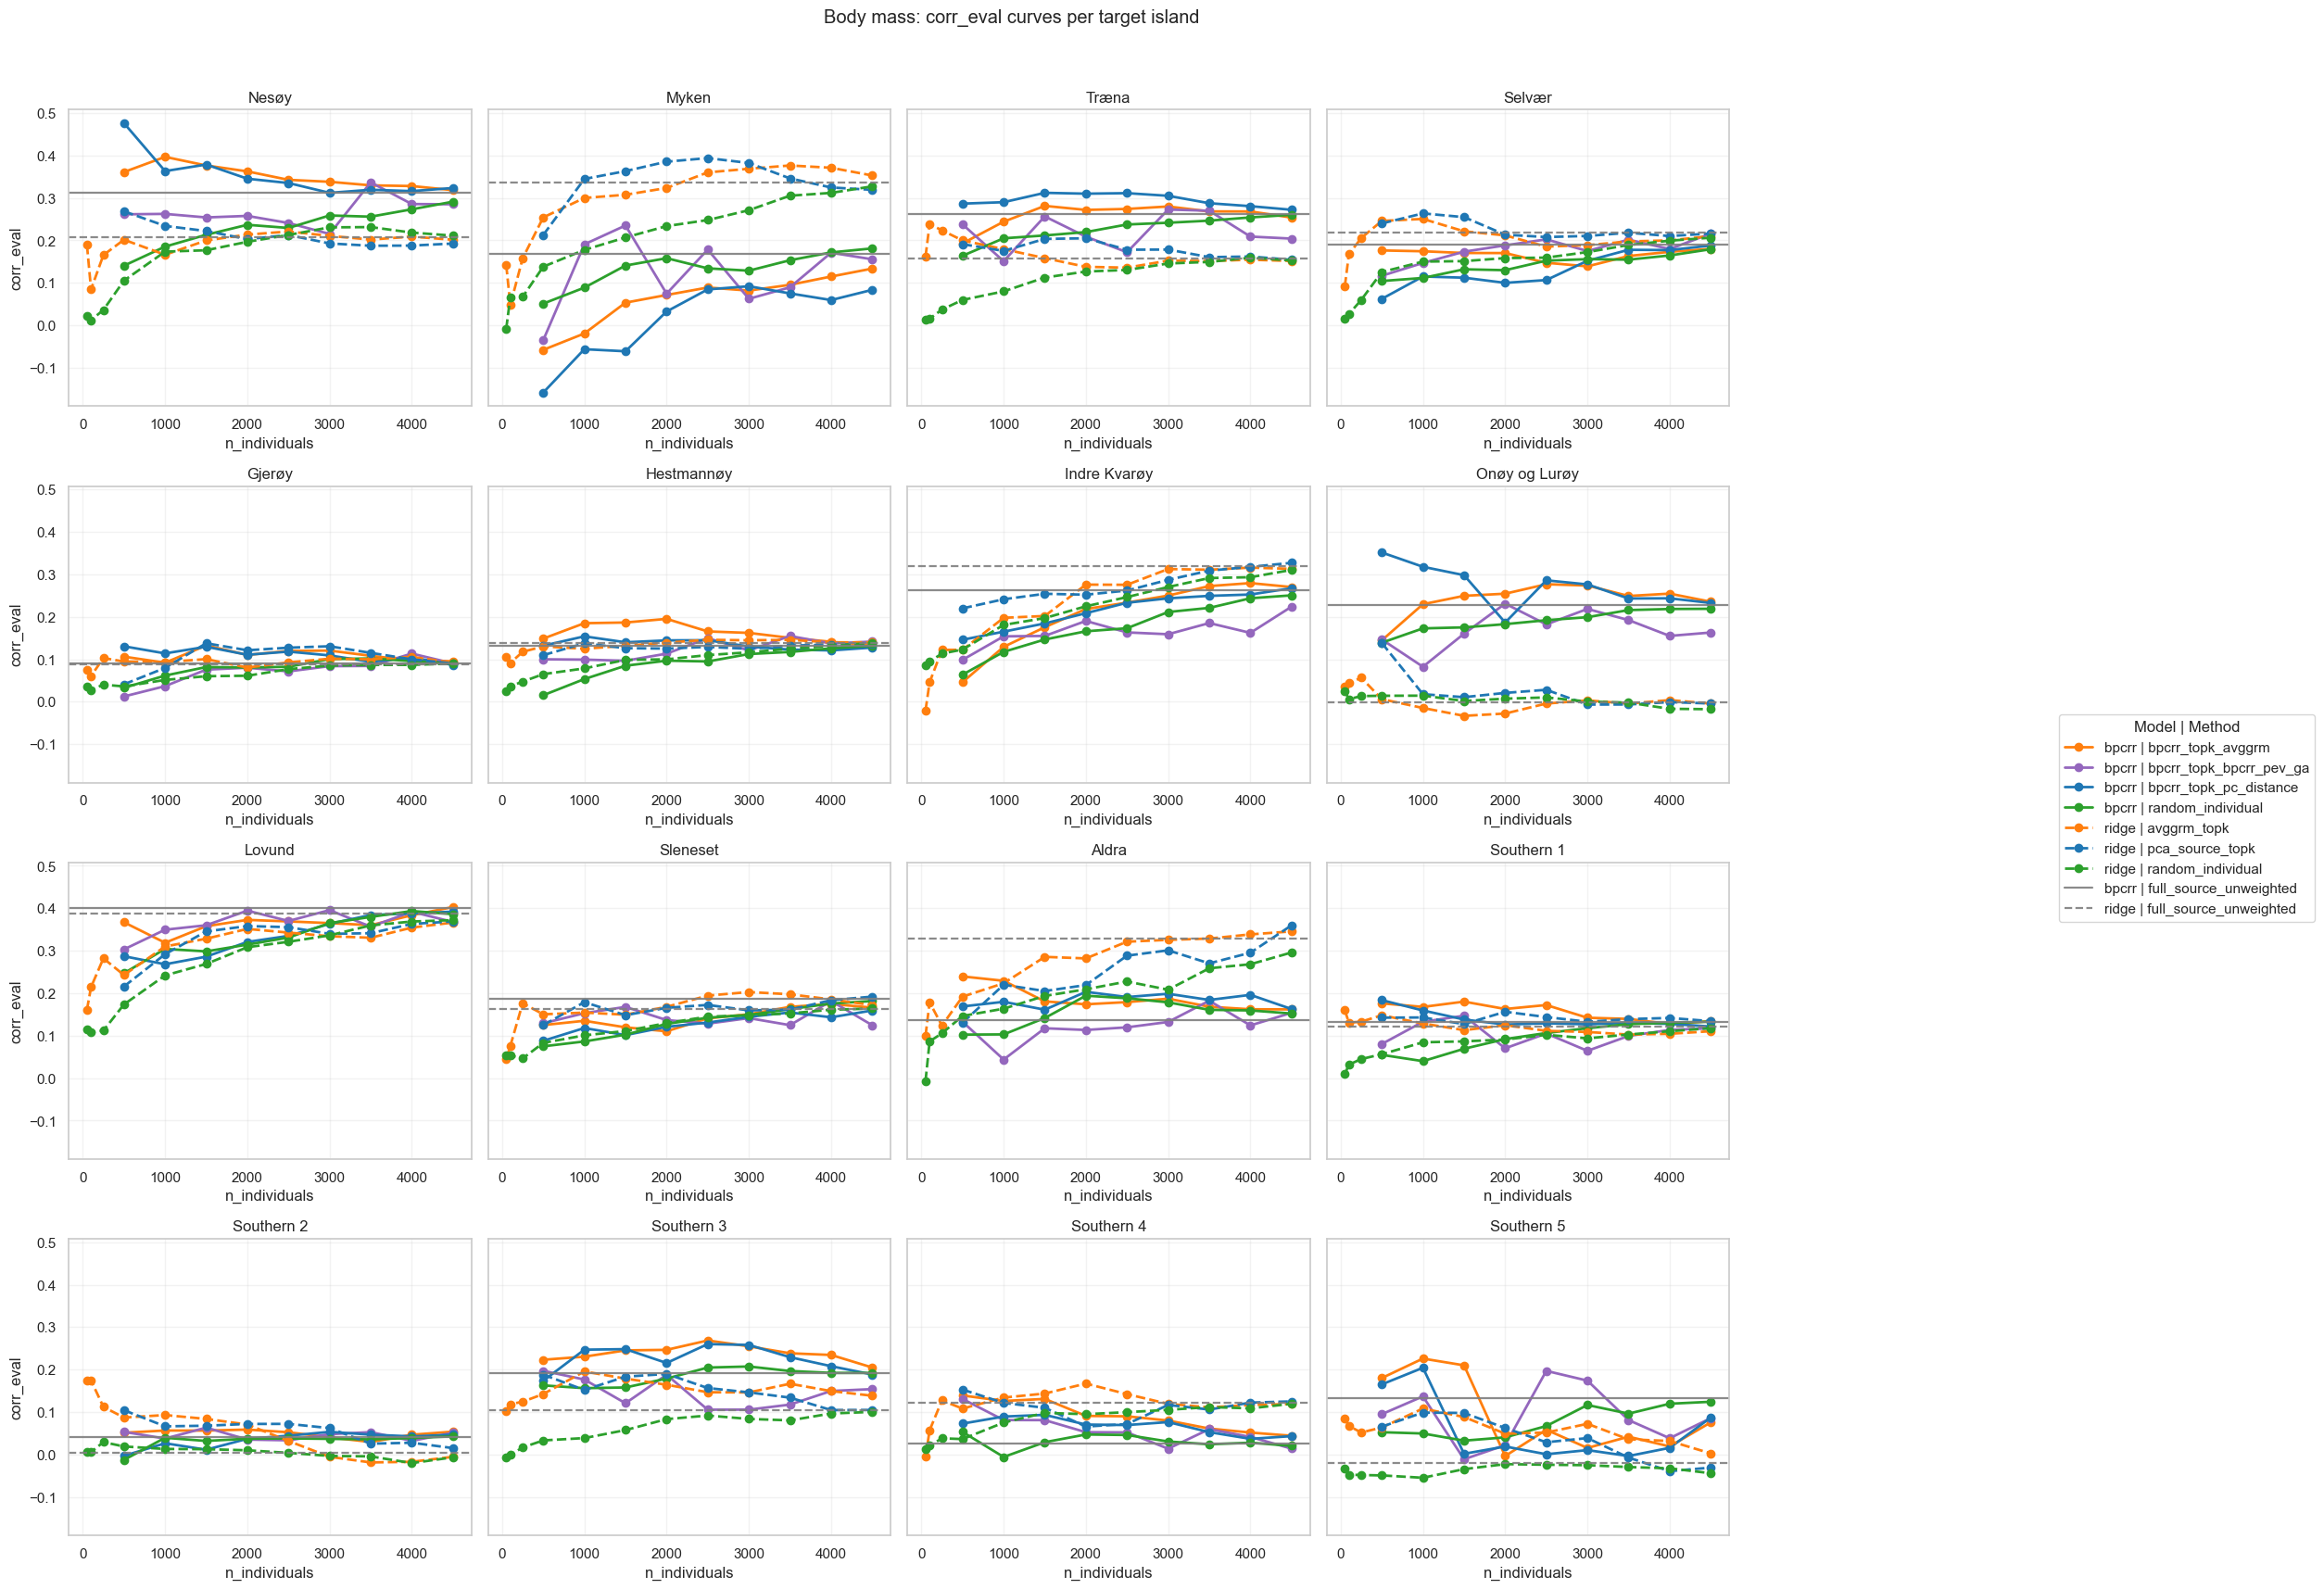

In [4]:
# Figure 2: one panel per target island
# Aggregate first to avoid overplotting duplicate runs/repeats at the same x value.
plot_island_df = (
    plot_data.groupby(["target_island", "model_display", "method", "n_individuals"], as_index=False)["corr_eval"]
    .mean()
    .sort_values(["target_island", "model_display", "method", "n_individuals"])
)
plot_island_df["curve"] = plot_island_df["model_display"] + " | " + plot_island_df["method"]

if plot_island_df.empty:
    raise ValueError("No rows to plot after filters. Relax PLOT_MODELS/PLOT_METHODS or USE_RANKED_SUBSET_ONLY.")

# Reuse deduplicated full-source references from the load cell.
panel_full_source_refs = full_source_refs.copy()

# Try to use real island names if present in any loaded table.
island_name_candidates = ["target_island_name", "target_name", "island_name", "target_island_label"]
island_name_map = {}
for col in island_name_candidates:
    if col in combined.columns:
        name_df = combined[["target_island", col]].dropna().drop_duplicates()
        if not name_df.empty:
            island_name_map = dict(zip(name_df["target_island"].astype(int), name_df[col].astype(str)))
            print(f"Using island labels from column: {col}")
            break


def island_title(island_id: int) -> str:
    island_name = island_name_map.get(int(island_id))
    if island_name is None or island_name.strip() == "":
        return f"Target island {island_id}"
    return str(island_name)


def method_family(method: str) -> str:
    m = str(method).lower()
    if "full_source" in m:
        return "full_source"
    if "random" in m:
        return "random"
    if "avggrm" in m:
        return "avggrm"
    if "delta_ld" in m:
        return "delta_ld"
    pc_tokens = ["pc_distance", "pca_source", "_pc_", "_pca_"]
    if any(tok in m for tok in pc_tokens) or m.startswith("pc_") or m.startswith("pca_"):
        return "pc"
    return "other"


def model_linestyle(model_display: str) -> str:
    return "-" if str(model_display).lower() == "bpcrr" else "--"


family_colors = {
    "random": "#2ca02c",
    "pc": "#1f77b4",
    "avggrm": "#ff7f0e",
    "delta_ld": "#d62728",
    "full_source": "#7f7f7f",
    "other": "#9467bd",
}

islands = sorted(plot_island_df["target_island"].unique().tolist())
n = len(islands)
if n == 0:
    raise ValueError("No target islands to plot after filtering")

n_cols = min(4, n)
n_rows = int(np.ceil(n / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4.2 * n_rows), sharey=True)
axes = np.array(axes).reshape(n_rows, n_cols)

curve_specs = (
    plot_island_df[["curve", "model_display", "method"]]
    .drop_duplicates()
    .sort_values(["model_display", "method"])
)

for i, island in enumerate(islands):
    r, c = divmod(i, n_cols)
    ax = axes[r, c]
    sub = plot_island_df[plot_island_df["target_island"] == island]

    for _, spec in curve_specs.iterrows():
        curve = spec["curve"]
        s = sub[sub["curve"] == curve]
        if s.empty:
            continue
        fam = method_family(spec["method"])
        ax.plot(
            s["n_individuals"],
            s["corr_eval"],
            marker="o",
            linewidth=2,
            color=family_colors.get(fam, family_colors["other"]),
            linestyle=model_linestyle(spec["model_display"]),
            label=curve,
        )

    fs_island = panel_full_source_refs[panel_full_source_refs["target_island"] == island]
    if not fs_island.empty:
        fs_model = fs_island.groupby("model_display", as_index=False)["corr_eval"].mean()
        for _, row in fs_model.iterrows():
            label = f"{row['model_display']} | full_source_unweighted"
            ax.axhline(
                row["corr_eval"],
                linestyle=model_linestyle(row["model_display"]),
                linewidth=1.6,
                alpha=0.9,
                color=family_colors["full_source"],
                label=label,
            )

    ax.set_title(island_title(island))
    ax.set_xlabel("n_individuals")
    if c == 0:
        ax.set_ylabel("corr_eval")
    ax.grid(True, alpha=0.25)

for j in range(n, n_rows * n_cols):
    r, c = divmod(j, n_cols)
    axes[r, c].axis("off")

handles, labels = [], []
for ax in axes.flatten():
    h, l = ax.get_legend_handles_labels()
    if l:
        handles, labels = h, l
        break
if handles:
    uniq = {}
    for h, l in zip(handles, labels):
        if l not in uniq:
            uniq[l] = h
    fig.legend(
        list(uniq.values()),
        list(uniq.keys()),
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        title="Model | Method",
    )

fig.suptitle("Body mass: corr_eval curves per target island", y=1.02)
fig.tight_layout(rect=[0, 0, 0.86, 1])
plt.show()

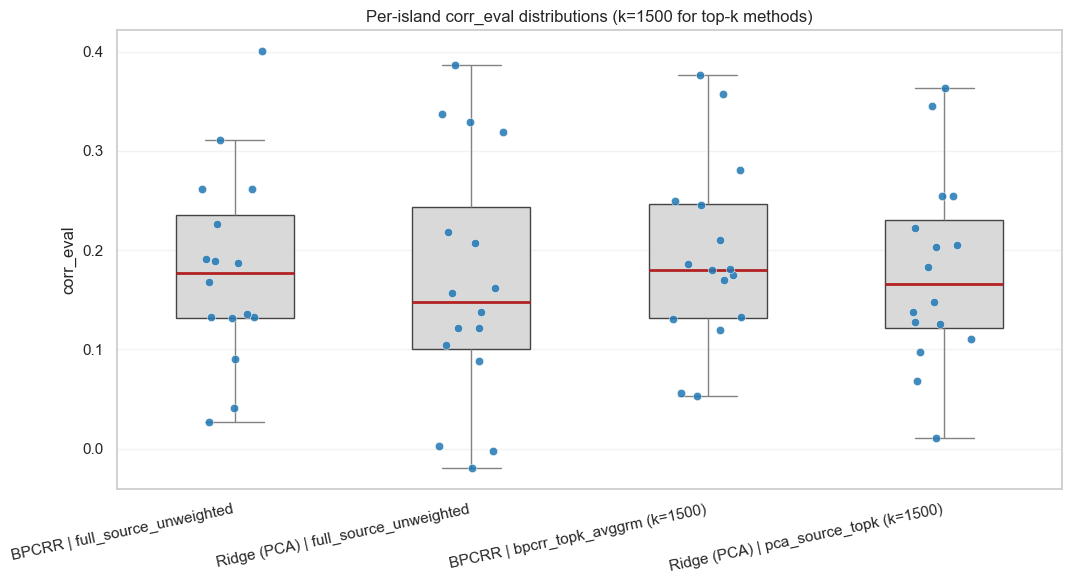

,index,box,n_islands,mean,median,std
0,0,BPCRR | bpcrr_topk_avggrm (k=1500),16,0.194102,0.180394,0.092006
1,1,BPCRR | full_source_unweighted,16,0.180368,0.177154,0.097138
2,2,Ridge (PCA) | full_source_unweighted,16,0.167013,0.147310,0.125603
3,3,Ridge (PCA) | pca_source_topk (k=1500),16,0.178548,0.165826,0.095318


In [5]:
# Figure 3: Boxplots of per-island performance for selected settings

# One point in each box = one target island (mean corr_eval within island if duplicates exist).
K_VALUE = 1500

box_specs = [
    {
        "label": "BPCRR | full_source_unweighted",
        "model": "bpcrr",
        "method": "full_source_unweighted",
        "n_individuals": None,
    },
    {
        "label": "Ridge (PCA) | full_source_unweighted",
        "model": "ridge_pca",
        "method": "full_source_unweighted",
        "n_individuals": None,
    },
    {
        "label": f"BPCRR | bpcrr_topk_avggrm (k={K_VALUE})",
        "model": "bpcrr",
        "method": "bpcrr_topk_avggrm",
        "n_individuals": K_VALUE,
    },
    {
        "label": f"Ridge (PCA) | pca_source_topk (k={K_VALUE})",
        "model": "ridge_pca",
        "method": "pca_source_topk",
        "n_individuals": K_VALUE,
    },
]

def collect_box_points(df: pd.DataFrame, spec: dict) -> pd.DataFrame:
    sub = df[(df["model"] == spec["model"]) & (df["method"] == spec["method"])].copy()

    if spec["n_individuals"] is not None:
        sub = sub[sub["n_individuals"] == spec["n_individuals"]]

    # Keep only target islands we currently focus on (same selection as earlier figures).
    sub = sub[sub["target_island"].isin(target_islands_to_plot)]

    if sub.empty:
        return pd.DataFrame(columns=["target_island", "corr_eval", "box"])

    # One point per island for the boxplot.
    points = sub.groupby("target_island", as_index=False)["corr_eval"].mean()
    points["box"] = spec["label"]
    return points

box_parts = [collect_box_points(combined, spec) for spec in box_specs]
box_df = pd.concat(box_parts, ignore_index=True)

if box_df.empty:
    raise ValueError("No rows found for the requested boxplot settings.")

# Enforce order even if some boxes are empty/missing.
box_order = [spec["label"] for spec in box_specs]
present_order = [label for label in box_order if label in box_df["box"].unique()]

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=box_df,
    x="box",
    y="corr_eval",
    order=present_order,
    color="#d9d9d9",
    width=0.5,
    showfliers=False,
    boxprops={"edgecolor": "#444444"},
    medianprops={"color": "#b22222", "linewidth": 2},
)

sns.stripplot(
    data=box_df,
    x="box",
    y="corr_eval",
    order=present_order,
    color="#1f77b4",
    size=6,
    alpha=0.85,
    jitter=0.15,
    edgecolor="white",
    linewidth=0.4,
)

plt.title(f"Per-island corr_eval distributions (k={K_VALUE} for top-k methods)")
plt.xlabel("")
plt.ylabel("corr_eval")
plt.xticks(rotation=12, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

summary = (
    box_df.groupby("box", as_index=False)["corr_eval"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
    .rename(columns={"count": "n_islands"})
)
display(summary)